# **06. Diversification and Correlations**
## **Overview**

The return of a security can be treated like a random variable. Using the historical return data of an asset, one can compute its expected returns and variance, and model its future trajectory using a stochastic model and the Monte Carlo simulation. However, this notebook will only explore gathering historical data, computing $E(R)$, $Var(R)$, and the covariance matrix. Refer to notebook 12 for stochastic models and Monte Carlo sims.

**Diversification is the only 'free lunch'** in portfolio management. This notebook will explore how portfolio variance shrinks as holdings increase from single stock → sector → market. 

However, the effects of diversification break down during extraordinary regimes and economic conditions just when you need it the most, and this notebook will explore this too.

### Learning Objectives  
By the end of this notebook, you will be able to:  
1. Estimate expected returns and return volatility from historical price data.
2. Understand how diversification reduces idiosyncratic risk, and what the covariance matrix is
4. Explain why diversification becomes less effective during market crises.
5. Compare correlation structures across normal and stressed market environments.

## Background

One of the oldest ideas in finance is deceptively simple:  
> **Don't put all your eggs in one basket!**

Diversification works because different assets rarely move perfectly together. Losses in one investment can often be offset by gains in another.  



Modern Portfolio Theory suggests that investors can reduce portfolio risk (measured with volatility, or the square root of variance) by combining assets whose returns are **not perfectly correlated**.

The total risk of an investment portfolio can be separated into:  
- **Idiosyncratic (diversifiable) risk** – company-specific events that can largely be eliminated through diversification.
- **Systematic (market) risk** – economy-wide shocks that affect nearly all assets simultaneously.


**But, this principle has an important limitation!**

During major financial crises, assets that normally behave independently suddenly begin moving together. Correlations between assets increase dramatically, causing diversification benefits to disappear precisely when investors need them the most.

### Part 1 — Historical Return Distributions
#### **1. Historical returns are realizations from some underlying random variable**  
We treat the return of a security, $R$, as a random variable:
$$
R ∼ \text{some unknown distribution}
$$

This implies that the return has population characteristics such as:

- Expected return:
$$
E(R) = \mu
$$

- Variance:
$$
Var(R) = \sigma^2
$$
Even if we do not know the exact distribution, these moments can still be defined.

##### Time frame of returns

The time frame for the returns we choose can be daily, monthly, yearly or any other time frames.

The shorter the time frame, i.e. daily, the more data points we have, but also the more noise we introduce into the sample set. The trade-off is that daily returns exhibit more market microstructure effects and stronger departures from the independent and identically distributed assumptions (e.g., volatility clustering), so higher frequency isn't always better for every application.

##### Returns vs Price
Why do we choose returns instead of price changes? In finance, returns are used instead of price changes because returns are relative and therefore comparable across different assets and time periods.

Also, we will use continuously compounded returns (log returns) instead of simple returns.
Log returns are calculated using the formula:
$$
r_t = \ln \left( \frac{P_t}{P_t-1} \right)
$$
Log returns are preferred because the total return after a period is the sum of the log periods of each sub period, i.e. $R_T = \sum\limits_{t=1}^{T} r_t$, whereas multiplication is needed due to the compounding effect when using simple returns, i.e. $R_T = \prod\limits_{t=1}^{T} r_t$.



##### **2. Estimation of moments from historical data**
Given our data set $\{r_1, r_2, r_3, \cdots, r_n\}$ we estimate:
1. **Expected return** $E(R)$
2. **Variance** $Var(R)$

Mathematically,
$$\hat{\mu} = \frac{1}{n} \sum\limits_{i=1}^{n} r_i$$
and
$$\hat{\sigma}^2 = \frac{1}{n-1} \sum\limits_{i=1}^{n} (r_i - \hat{\mu})^2$$

##### **3. We do not assume the distribution of historical returns for a specific security.**
Instead, we may say:
> Future returns are generated by an unknown probability distribution with characteristics that can be estimated from historical data.

This approach is called nonparametric moment estimation (or distribution-free estimation of moments)

For example, historical returns may have:
- fat tails (more extreme events than a normal distribution predicts)
- skewness (more large losses than gains)
- volatility clustering
- changing variance over time

So assuming normality may be unrealistic.

##### **4. Example using Apple stock**
Below, we will employ the methods mentioned above to calculate the parameters for Apple stock (ticker: AAPL).

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The monthly returns are gathered from ```../data/stock_data/aapl_us_m.csv```. This stock data csv file is downloaded from [Stooq](https://stooq.com/).

In [3]:
aapl = pd.read_csv("../data/stock_data/aapl_us_m.csv")
aapl["Date"] = pd.to_datetime(aapl["Date"])

aapl = (
    aapl
    .set_index("Date")
    .sort_index()
)

The monthly returns have to be converted to log returns by taking the logarithm of the fraction of the closing price of the next day to the closing price of the previous day.

In [4]:
monthly_log_returns = np.log(
    aapl["Close"] /
    aapl["Close"].shift(1)
).dropna()
# monthly_log_returns = monthly_log_returns.to_frame(
#     name="AAPL_Log_Return"
# )
#monthly_log_returns.head()

With the log returns collated, we can use the formulas above to calculate the mean return and volatility. We can get the annualised return by multipling the mean monthly return with $12$ since we are summing the monthly mean return $12$ times statistically. The annualised volatility is found by multipling $\sqrt{12}$ to the variance. The results are tabulated.

In [42]:
mean_return = monthly_log_returns.mean()
variance = monthly_log_returns.var()
volatility = monthly_log_returns.std()
annual_return = mean_return * 12
annual_volatility = volatility * np.sqrt(12)
#print(f"Mean monthly return: {mean_return*100:.4f} %\nVariance: {variance:.4f}\nAnnual Return: {annual_return*100:.2f} %\nAnnual Volatility: {annual_volatility*100:.2f} %")

apple_table = pd.DataFrame({
    "Mean Monthly Return (%)": [round(mean_return*100,4)],
    "Variance": [round(variance,4)],
    "Volatility": [round(volatility,4)],
    "Annual Return (%)": [round(annual_return*100,2)],
    "Annual Volatility": [round(annual_volatility*100,2)]
},
index=["AAPL"])

apple_table.style \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]}
    ])

,Mean Monthly Return (%),Variance,Volatility,Annual Return (%),Annual Volatility
AAPL,1.593900,0.014900,0.122000,19.130000,42.250000


The time series of monthly log returns of Apple stock is plotted below:

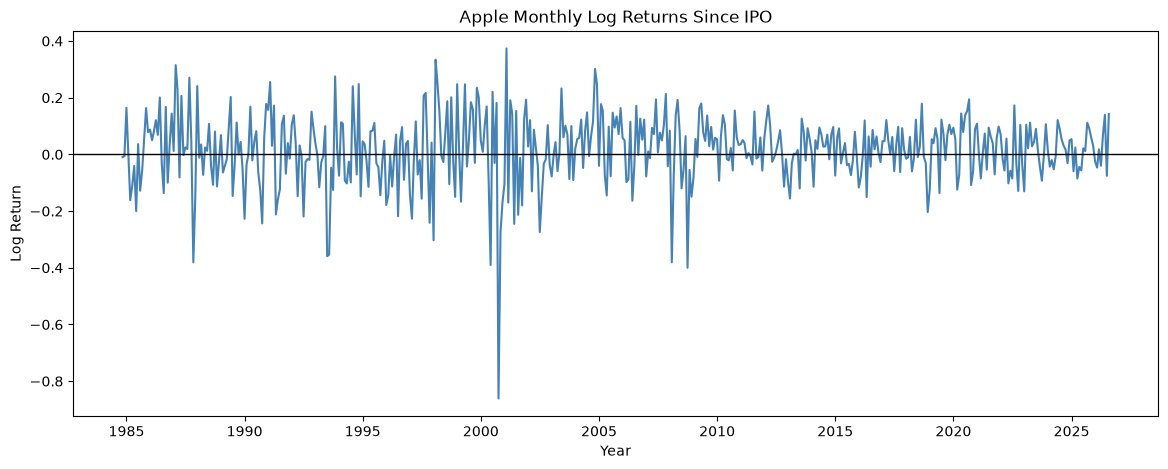

In [6]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_log_returns,
    color="steelblue"
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Apple Monthly Log Returns Since IPO"
)

plt.ylabel(
    "Log Return"
)

plt.xlabel(
    "Year"
)

plt.show()

With the sample of monthly returns, we can plot a histogram that shows the distribution of returns. 

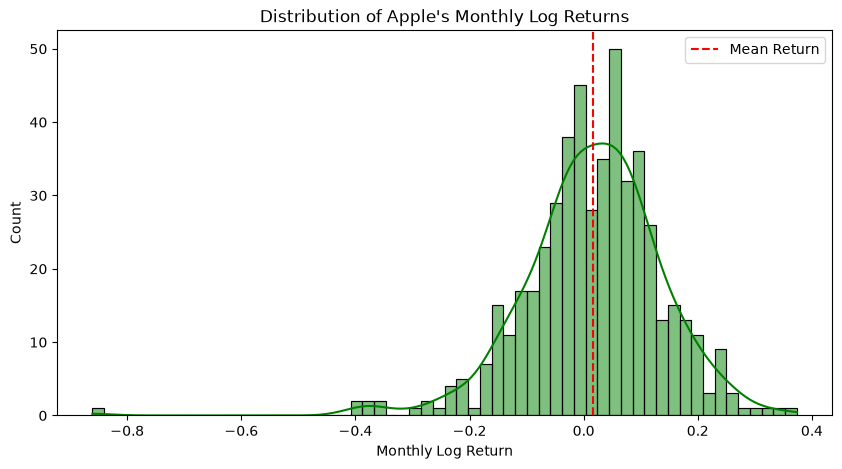

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    monthly_log_returns,
    bins=60,
    kde=True,
    color="green"
)

plt.axvline(
    mean_return,
    color="red",
    linestyle="--",
    label="Mean Return"
)

plt.title(
    "Distribution of Apple's Monthly Log Returns"
)

plt.xlabel(
    "Monthly Log Return"
)

plt.legend()

plt.show()

Some observations:
1. There is an extreme negative outlier (return around $-0.85$).
2. There are more observations in the tails, beyond roughly $±0.20$, especially on the positive side.
3. There is a sharper central peak, a hallmark of leptokurtic distributions (positive excess kurtosis).

This can be confirmed by using the scipy library to compute skewness and excess kurtosis:

In [17]:
from scipy.stats import kurtosis, skew

print("Skewness:", skew(monthly_log_returns))
print("Excess kurtosis:", kurtosis(monthly_log_returns))

Skewness: -1.0341847093405254
Excess kurtosis: 5.579681114638529


With an Excess kurtosis of more than $0$, it suggests that the distribution is leptokurtic (fat tails). 

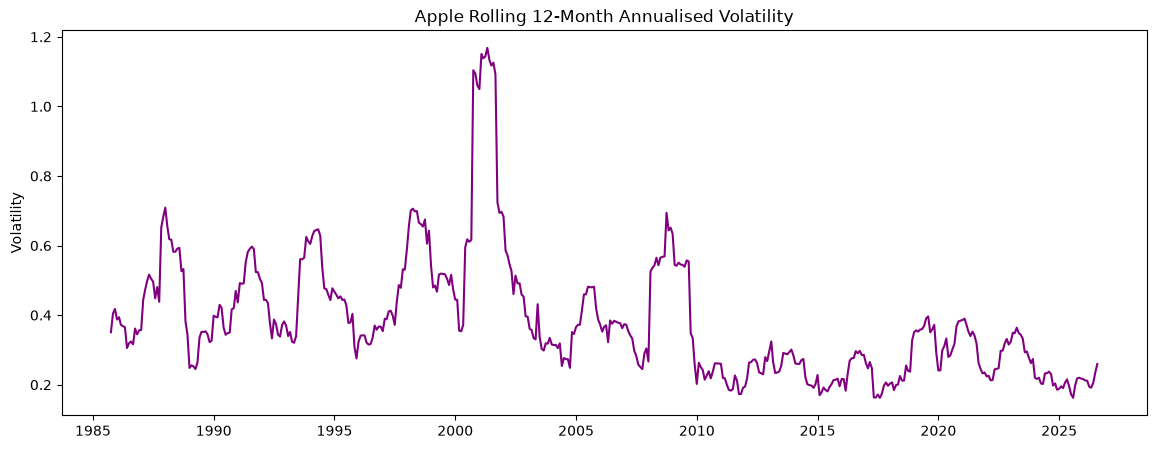

In [8]:
rolling_vol = (
    monthly_log_returns
    .rolling(12)
    .std()
    * np.sqrt(12)
)
plt.figure(figsize=(14,5))

plt.plot(
    rolling_vol,
    color="purple"
)

plt.title(
    "Apple Rolling 12-Month Annualised Volatility"
)

plt.ylabel(
    "Volatility"
)

plt.show()

### Part 2 — How diversification reduces risk

A more volatile portfolio is riskier.

A volatile portfolio may force you to sell for 70 cents on the dollar in a great drawdown.

In this section we will compare three portfolios:
1. 100% Apple shares
2. 100% Technology sector ETF (which is a basket of tech stocks like Apple)
3. 50% Technology sector ETF + 50% Healthcare sector ETF

In [11]:
assets = [
    "AAPL",
    "XLK",
    "XLV"
]

def load_monthly_returns(ticker):

    df = pd.read_csv(
        f"../data/stock_data/portfolios/{ticker}.csv",
        parse_dates=["Date"]
    )

    df = (
        df
        .set_index("Date")
        .sort_index()
    )

    monthly_price = (
        df["Close"]
        .resample("ME")
        .last()
    )

    returns = np.log(
        monthly_price /
        monthly_price.shift(1)
    )

    return returns.dropna()

returns = pd.DataFrame()

for asset in assets:

    returns[asset] = load_monthly_returns(asset)

returns = returns.dropna()

aapl_portfolio = returns["AAPL"]
tech_portfolio = returns["XLK"]
diversified_portfolio = (
    0.5 * returns["XLK"] +
    0.5 * returns["XLV"]
)

The annual volatility of each portfolio is presented as below.

In [36]:
volatility = pd.DataFrame({

    "Portfolio":[
        "AAPL",
        "Technology ETF",
        "Technology + Healthcare"
    ],

    "Annual Volatility":[

        aapl_portfolio.std()*np.sqrt(12),

        tech_portfolio.std()*np.sqrt(12),

        diversified_portfolio.std()*np.sqrt(12)

    ]
})
volatility.style \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]}
    ]) \
    .hide(axis="index")

Portfolio,Annual Volatility
AAPL,0.306854
Technology ETF,0.188479
Technology + Healthcare,0.144403


It is apparent that volatility of the overall portfolio **decreases** when you have:

1) Multiple tech stocks compared to holding one tech stock
2) Multiple industries compared to holding one industry

Consequently, the maximum drawdonws decreases when your portfolio becomes more diversified. This also supports the view that volatility decreases when you have a more diverse portfolio.

In [33]:
def max_drawdown(returns):

    wealth = np.exp(
        returns.cumsum()
    )

    peak = wealth.cummax()

    drawdown = (wealth / peak - 1)*100

    return drawdown.min()

max_drawdown_table = pd.DataFrame({

"Portfolio":[
    "AAPL",
    "XLK",
    "50% XLK + 50% XLV"
],

"Maximum Drawdown":[

    f"{max_drawdown(aapl_portfolio):.2f}%",

    f"{max_drawdown(tech_portfolio):.2f}%",

    f"{max_drawdown(diversified_portfolio):.2f}%"

]

})

max_drawdown_table.style \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]}
    ]) \
    .hide(axis="index")

Portfolio,Maximum Drawdown
AAPL,-56.91%
XLK,-50.28%
50% XLK + 50% XLV,-43.67%


In [14]:
aapl_index = np.exp(
    aapl_portfolio.cumsum()
)

tech_index = np.exp(
    tech_portfolio.cumsum()
)

diversified_index = np.exp(
    diversified_portfolio.cumsum()
)

index_values = pd.DataFrame({

    "AAPL": aapl_index,

    "Technology ETF": tech_index,

    "Tech + Healthcare": diversified_index

})

#### Eliminating idiosyncratic risk

Apple experienced a major drawdown after reaching its 2012 peak due to:
1. slowing iPhone growth
2. margin pressure
3. competition concerns

However, the broader technology sector was less affected, because this issue was **unique** to Apple only. This is shown by how a technology portfolio was up 10% whereas a portfolio consisting of Apple stock only was down about 23% at the end of this window.

Hence, owning the sector rather than one company reduces company-specific shocks (idiosyncratic risks).

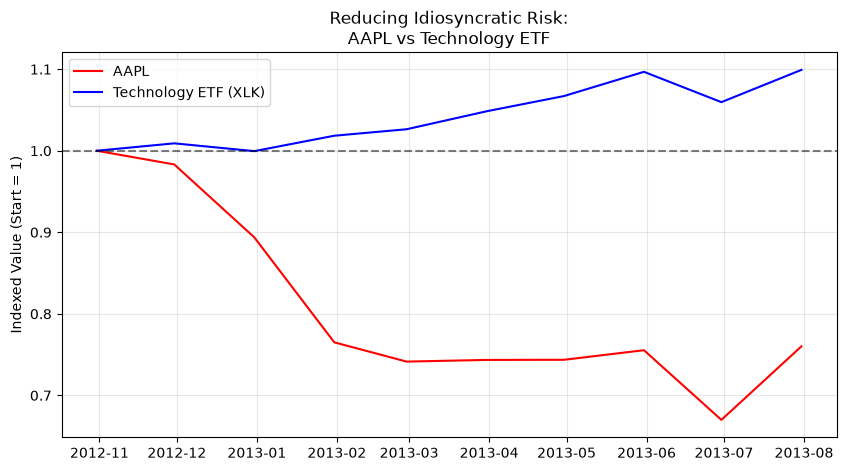

In [15]:
idiosyncratic = index_values[
    ["AAPL", "Technology ETF"]
].loc[
    "2012-10-01":"2013-07-31"
]


idiosyncratic = (
    idiosyncratic /
    idiosyncratic.iloc[0]
)

plt.figure(figsize=(10,5))

plt.plot(
    idiosyncratic["AAPL"],
    label="AAPL",
    color="red"
)

plt.plot(
    idiosyncratic["Technology ETF"],
    label="Technology ETF (XLK)",
    color="blue"
)


plt.axhline(
    1,
    color="black",
    linestyle="--",
    alpha=0.5
)

plt.title(
    "Reducing Idiosyncratic Risk:\nAAPL vs Technology ETF"
)

plt.ylabel(
    "Indexed Value (Start = 1)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Eliminating industry risk

In 2022, there was high interest-rate sensitivity, causing a great repricing of large growth stock like tech stocks. On the other hand, healthcare stocks which had defensive characteristics and stable demand were less affected by higher interest rates.

Thus, the drawdown in a tech+healthcare portfolio was less than that of a purely tech portfolio, showing that industry risk can be diversified away by holding different industries in a portfolio.

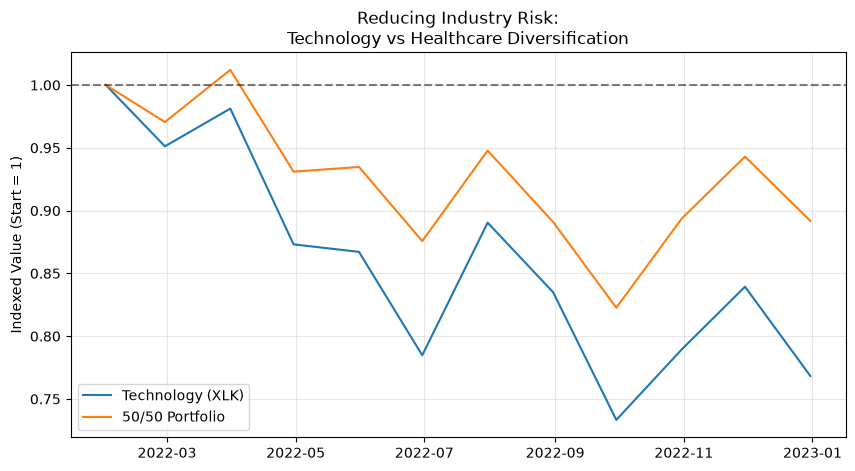

In [16]:
industry = pd.DataFrame({
    "XLK": index_values["Technology ETF"],
    "50/50 Tech-Healthcare": index_values["Tech + Healthcare"]
})


industry = industry.loc[
    "2022-01-01":"2023-01-15"
]


industry = industry / industry.iloc[0]

plt.figure(figsize=(10,5))


plt.plot(
    industry["XLK"],
    label="Technology (XLK)"
)


plt.plot(
    industry["50/50 Tech-Healthcare"],
    label="50/50 Portfolio",
)


plt.axhline(
    1,
    color="black",
    linestyle="--",
    alpha=0.5
)


plt.title(
    "Reducing Industry Risk:\nTechnology vs Healthcare Diversification"
)

plt.ylabel(
    "Indexed Value (Start = 1)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Part 3 — Holding the market portfolio - The end of diversification?

Moving on from holding two industries in a portfolio, the end goal of diversification necessarily implies the holding of all industries, all stocks, of a particular market.

One of the most popular ETFs, VTI, which tracks the CRSP U.S. Total Market Index, holds every publicly traded U.S. company, each weighted by their market capitalisation.

How, then, does one calculate the $\operatorname{E}(R)$ and $\operatorname{Var}(R)$ of a portfolio consisting of many stocks, each with their own return distributions? How do we mathematically prove that overall portfolio volatility decreases when more stocks are involved?

Let $r_p$ be the return of the portfolio, a random variable. This portfolio has 2 assets $a$ and $b$, with $r_a$ and $r_b$ as the returns respectively. Denote the proportion of $a$ and $b$ in the portfolio as $w_a$ and $w_b$ respectively where $w_a+w_b=1$. Thus, $r_p=w_ar_a+w_br_b$.

Statistically, $$\operatorname{E}(r_p)=\operatorname{E}(w_ar_a)+\operatorname{E}(w_br_b)$$ which we can expand to become $$\operatorname{E}(r_p)=w_a\operatorname{E}(r_a)+w_b\operatorname{E}(r_b)$$

For variance, by definition,
$$

\begin{aligned}
\operatorname{Var}(r_p) &= \operatorname{E}[(r_p-\operatorname{E}(r_p))^2] \\
&= \operatorname{E}[\left( w_a(r_a-\operatorname{E}(r_a))+ (1-w_a)(r_b-\operatorname{E}(r_b))\right)^2] \\
&= \operatorname{E}[w_a^2(r_a-\operatorname{E}(r_a))^2 + (1-w_a)^2(r_b-\operatorname{E}(r_b))^2 + 2(w_a)(1-w_a)(r_a-\operatorname{E}(r_a))(r_b-\operatorname{E}(r_b))]\\
&= w_a^2\operatorname{E}[(r_a-\operatorname{E}(r_a))^2] + (1-w_a)^2\operatorname{E}[(r_b-\operatorname{E}(r_b))^2] + 2(w_a)(1-w_a)\operatorname{E}[(r_a-\operatorname{E}(r_a))(r_b-\operatorname{E}(r_b))]\\
&= w_a^2\sigma _a^2 + (1-w_a)^2 \sigma _b^2 + 2(w_a)(1-w_a)\operatorname{Cov}(r_a,r_b)
\end{aligned}
$$

This just means that our portfolio's variance is dependent on three components:
1. the variance of $r_a$: $\sigma _a^2$
2. the variance of $r_b$: $\sigma _b^2$
3. the covariance between $r_a$ and $r_b$: $\operatorname{Cov}(r_a,r_b)$

How does covariance relate to correlation? By definition, covariance is related to correlation by: $$\operatorname{Cov}(r_a,r_b) = {\rho}_{a,b} \sigma _a \sigma _b $$ where ${\rho}_{a,b}$ is the correlation between $r_a$ and $r_b$. Thus,
$$
\operatorname{Var}(r_p) = w_a^2\sigma _a^2 + (1-w_a)^2 \sigma _b^2 + 2(w_a)(1-w_a){\rho}_{a,b} \sigma _a \sigma _b
$$

This is where the puzzle fits together. So long as ${\rho}_{a,b} < 1$, the term $2(w_a)(1-w_a){\rho}_{a,b} \sigma _a \sigma _b$ is going to shrink, reducing $\operatorname{Var}(r_p)$. Hence, this mathematically proves that having more stocks that have **low correlation** in a portfolio reduces portfolio standard deviation $\sigma _p$.

In general, for a portfolio of $n$ stocks, the portfolio variance can be written as:
$$
\operatorname{Var}(r_p) = \sum\limits_{i=1}^{n} \sum\limits_{j=1}^{n} {w_i}{w_j} \operatorname{Cov}(r_i, r_j)
$$

since $\operatorname{Cov}(r_i, r_i) = \sigma _i^2$.

In conclusion,
For $n$ assets, variance of portfolio is the sum of:
1. Individual risks ($n$ terms)
    - Each asset’s own variance, scaled by its weight squared.

2. Interaction risks ($n$ choose $2$ pairs)
    - $2(w_i)(w_j)$ times the Covariance of every possible pair of assets $i$ and $j$.


##### **Correlation Matrix**
The covariance of every possible pair of assets can be represented with a 2D vector.
$$
\Sigma =
\begin{bmatrix}
\sigma_1^2 & \sigma_{12} & \sigma_{13} & \cdots & \sigma_{1n} \\
\sigma_{21} & \sigma_2^2 & \sigma_{23} & \cdots & \sigma_{2n} \\
\sigma_{31} & \sigma_{32} & \sigma_3^2 & \cdots & \sigma_{3n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\sigma_{n1} & \sigma_{n2} & \sigma_{n3} & \cdots & \sigma_n^2
\end{bmatrix}
$$
In general, a covariance matrix of $n$ asset returns will have:
1. $n^2$ elements
2. $n$ variance elements along the diagonal ($\sigma ^2$)
3. $n^2-n=n(n-1)$ covariance elements (those not on diagonal)
4. $\frac{1}{2}n(n-1)$ unique covariance elements (discounting repeated covariance elements)


##### **Correlations go to 1**
There seems to be a common pattern: during market stress, many assets that usually move somewhat independently begin falling together. This means that average correlations increase.

The main reason why this happens is because of broad market sell-offs due to fear, risk-off events, and institutional flight to safety. Assets sharing the same dominant risk factor become much more correlated when that factor overwhelms individual differences.

If correlations increase during a market downturn, then the off-diagonal covariance terms increases, reducing the diversification benefit.

In the extreme case where all pairwise correlations approach 1, the covariance matrix becomes dominated by common movement, and the portfolio behaves much more like a single asset. This is the mathematical reason diversification tends to be less effective during periods of market stress.

##### **Key Takeaway**
_Diversification is effective in mitigating idiosyncratic risk under normal market conditions. However, during periods of financial stress, cross-asset correlations tend to rise as common systematic risk factors dominate return dynamics. The resulting increase in the covariance matrix reduces the effectiveness of diversification, causing even broad market portfolios to experience significant drawdowns._

_Investors earn the market risk premium for holding on to the market portfolio, for enduring the potential drawdowns that persists even when all idiosyncratic and industry risks are diversified away. The remaining risk that diversification does not eliminate is called **systematic risk**._



